# Minimal Tesseract OCR Test

This notebook:
1. Generates a placeholder receipt image (so no upload is needed)
2. Runs Tesseract OCR on it via `pytesseract`
3. Does a naive parse of line items + prices from the raw text

Run this notebook using the `ocr_env` virtual environment created alongside it — no system-wide installs needed beyond the `tesseract` binary itself (via `brew install tesseract` on Mac, or `apt install tesseract-ocr` on Linux).

In [1]:
import re
import pytesseract
from PIL import Image, ImageDraw, ImageFont

print("Tesseract version:", pytesseract.get_tesseract_version())

Tesseract version: 5.3.4


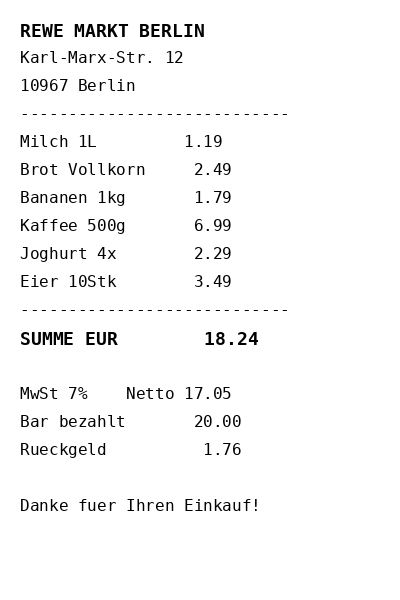

In [2]:
# --- Generate a placeholder receipt image ---

width, height = 400, 600
img = Image.new("RGB", (width, height), color="white")
draw = ImageDraw.Draw(img)

try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf", 16)
    font_bold = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSansMono-Bold.ttf", 18)
except Exception:
    font = ImageFont.load_default()
    font_bold = font

lines = [
    ("REWE MARKT BERLIN", font_bold),
    ("Karl-Marx-Str. 12", font),
    ("10967 Berlin", font),
    ("-" * 28, font),
    ("Milch 1L         1.19", font),
    ("Brot Vollkorn     2.49", font),
    ("Bananen 1kg       1.79", font),
    ("Kaffee 500g       6.99", font),
    ("Joghurt 4x        2.29", font),
    ("Eier 10Stk        3.49", font),
    ("-" * 28, font),
    ("SUMME EUR        18.24", font_bold),
    ("", font),
    ("MwSt 7%    Netto 17.05", font),
    ("Bar bezahlt       20.00", font),
    ("Rueckgeld          1.76", font),
    ("", font),
    ("Danke fuer Ihren Einkauf!", font),
]

y = 20
for text, f in lines:
    draw.text((20, y), text, fill="black", font=f)
    y += 28

img.save("sample_receipt.png")
img

In [3]:
# --- Run Tesseract OCR ---

def run_ocr(image_path: str) -> str:
    img = Image.open(image_path)
    config = "--psm 6"  # assume a single uniform block of text
    return pytesseract.image_to_string(img, config=config)

raw_text = run_ocr("sample_receipt.png")
print(raw_text)

REWE MARKT BERLIN
Karl-Marx-Str. 12

10967 Berlin

Mitch 1L 1.19
Brot Vollkorn 2.49
Bananen 1kg 1.79
Kaffee 500g 6.99
Joghurt 4x 2.29
Eier 10Stk 3.49
SUMME EUR 18.24
MwSt 7% Netto 17.05
Bar bezahit 20.00
Rueckgeld 1.76
Danke fuer Ihren Einkauf!



In [4]:
# --- Naive line-item parser ---

def parse_items(raw_text: str):
    price_pattern = re.compile(r"^(.*?)\s+(\d+[.,]\d{2})\s*$")
    items = []
    for line in raw_text.splitlines():
        line = line.strip()
        if not line:
            continue
        match = price_pattern.match(line)
        if match:
            label, price = match.groups()
            items.append({"label": label.strip(), "price": price.replace(",", ".")})
    return items

items = parse_items(raw_text)
for item in items:
    print(f"{item['label']:<25} {item['price']}")

Mitch 1L                  1.19
Brot Vollkorn             2.49
Bananen 1kg               1.79
Kaffee 500g               6.99
Joghurt 4x                2.29
Eier 10Stk                3.49
SUMME EUR                 18.24
MwSt 7% Netto             17.05
Bar bezahit               20.00
Rueckgeld                 1.76


### Notes

- Even on this clean, computer-generated image, Tesseract may misread a word or two (e.g. "Milch" → "Mitch"). Real photographed receipts (crumpled, tilted, low light) will be noisier.
- To improve accuracy: preprocess the image first (grayscale, deskew, increase contrast/binarize) before passing it to Tesseract.
- For messier real-world receipts, an alternative worth testing is Claude Vision (or AWS Textract) — often handles noisy photos better without a preprocessing pipeline, at the cost of needing an API call.